In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# NCBI Taxonomy Graph

In [2]:
RANKS = ["Realm", "Kingdom", "Phylum", "Class", "Order", "Family",  "Genus", "Species"]
### Load names
names = {}
with open("names.dmp") as f:
    for line in f:
        parts = [p.strip() for p in line.split("|")]
        if parts[3] == "scientific name":
            names[int(parts[0])] = parts[1]

# ### Load nodes (parent-child relationships)
# G_ncbi = nx.DiGraph()
# with open("nodes.dmp") as f:
#     for line in f:
#         parts = [p.strip() for p in line.split("|")]
#         child_id  = int(parts[0])
#         parent_id = int(parts[1])
#         rank      = parts[2]
#         if child_id != parent_id:  # root points to itself
#             child_name  = names.get(child_id, str(child_id))
#             parent_name = names.get(parent_id, str(parent_id))
#             G_ncbi.add_edge(parent_name, child_name,
#                             rank=rank, taxid=child_id)

# print(f"Full NCBI tree: {G_ncbi.number_of_nodes()} nodes")

# ### Filter to a subtree (e.g., just Viruses)
# def get_subtree(G, root_name):
#     descendants = nx.descendants(G, root_name)
#     descendants.add(root_name)
#     return G.subgraph(descendants).copy()

# G_viruses = get_subtree(G_ncbi, "Viruses")

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



['3473165', 'Coccinella picta', 'Coccinella picta <Psyllobora picta>', 'synonym', '']
['3473165', 'Coccinella picta Germain, 1854', '', 'authority', '']
['3473165', 'Psyllobora picta (Germain, 1854)', '', 'authority', '']
['3473165', 'Psyllobora picta', '', 'scientific name', '']
['3473166', 'Caridina sp. T74458-1', '', 'scientific name', '']
['3473169', 'Eutus sp. T74479-1', '', 'scientific name', '']
['3473170', 'Holotrichius apterus Jakovlev, 1879', '', 'authority', '']
['3473170', 'Holotrichius apterus', '', 'scientific name', '']
['3473171', 'Oncocephalus plumicornis (Germar, 1822)', '', 'authority', '']
['3473171', 'Oncocephalus plumicornis', '', 'scientific name', '']
['3473171', 'Reduvius plumicornis', '', 'synonym', '']
['3473172', 'Pasira basiptera', '', 'scientific name', '']
['3473172', 'Pasira basiptera Stal, 1859', '', 'authority', '']
['3473173', 'Brachygobius sp. T7119-1', '', 'scientific name', '']
['3473179', 'Gadella sp.', '', 'scientific name', '']
['3473180', 'Anod

In [35]:
# Basic stats
print(f"Nodes: {G_ncbi.number_of_nodes()}")
print(f"Edges: {G_ncbi.number_of_edges()}")

# Peek at nodes and edges
print("Sample nodes:", list(G_ncbi.nodes)[:10])
print("Sample edges:", list(G_ncbi.edges)[:10])

# Check a specific node's children
node = "Viruses"
print(f"\nChildren of '{node}':", list(G_ncbi.successors(node)))
print(f"Parent of '{node}':",    list(G_ncbi.predecessors(node)))

# See the distribution of ranks
import pandas as pd
ranks = nx.get_edge_attributes(G_ncbi, 'rank')
pd.Series(ranks.values()).value_counts().head(20)

Nodes: 2719514
Edges: 2727584
Sample nodes: ['cellular organisms', 'Bacteria', 'Xanthobacteraceae', 'Azorhizobium', 'Azorhizobium caulinodans', 'Buchnera', 'Buchnera aphidicola', 'Cellvibrionaceae', 'Cellvibrio', 'Cellulomonas']
Sample edges: [('cellular organisms', 'Bacteria'), ('cellular organisms', 'Archaea'), ('cellular organisms', 'Eukaryota'), ('Bacteria', 'Bacteria incertae sedis'), ('Bacteria', 'environmental samples'), ('Bacteria', 'unclassified Bacteria'), ('Bacteria', 'delta/epsilon subdivisions'), ('Bacteria', 'Bacillati'), ('Bacteria', 'Candidatus Krumholzibacteriota'), ('Bacteria', 'Candidatus Tharpellota')]

Children of 'Viruses': ['unclassified bacterial viruses', 'unclassified viruses', 'environmental samples', 'Riboviria', 'Duplodnaviria', 'Monodnaviria', 'Varidnaviria', 'Adnaviria', 'Ribozyviria', 'Viruses incertae sedis', 'Singelaviria']
Parent of 'Viruses': ['root']


species            2240876
no rank             254609
genus               113807
strain               47014
subspecies           31201
family               10892
varietas             10491
subfamily             3338
tribe                 2421
order                 2081
subgenus              1885
isolate               1301
clade                  925
superfamily            908
forma specialis        843
forma                  738
class                  597
serotype               570
subtribe               570
section                561
dtype: int64

In [31]:
# TARGET_RANKS = {r.lower() for r in RANKS}
# print(TARGET_RANKS)

# # Filter NCBI graph to only nodes whose rank is in your target set
# def filter_ncbi_to_ranks(G, target_ranks):
#     """Keep only nodes matching target ranks, rewire edges to skip intermediates."""
#     G_filtered = nx.DiGraph()
    
#     # Get rank attribute per node
#     node_ranks = nx.get_node_attributes(G, 'rank')  # if you stored rank on nodes
#     # OR derive from edge attributes if you stored rank on edges
    
#     # Find nodes that match target ranks
#     keep = {n for n, r in node_ranks.items() if r.lower() in target_ranks}
    
#     # For each kept node, find its nearest kept ancestor
#     for node in keep:
#         # Walk up the tree to find the nearest ancestor also in 'keep'
#         current = node
#         while True:
#             parents = list(G.predecessors(current))
#             if not parents:
#                 break
#             current = parents[0]
#             if current in keep:
#                 G_filtered.add_edge(current, node)
#                 break
    
#     return G_filtered

# G_ncbi_filtered = filter_ncbi_to_ranks(G_ncbi, TARGET_RANKS)

In [32]:
# # Basic stats
# print(f"Nodes: {G_ncbi_filtered.number_of_nodes()}")
# print(f"Edges: {G_ncbi_filtered.number_of_edges()}")

# # Peek at nodes and edges
# print("Sample nodes:", list(G_ncbi_filtered.nodes)[:10])
# print("Sample edges:", list(G_ncbi_filtered.edges)[:10])

# # Check a specific node's children
# node = "Viruses"
# # print(f"\nChildren of '{node}':", list(G_ncbi_filtered.successors(node)))
# # print(f"Parent of '{node}':",    list(G_ncbi_filtered.predecessors(node)))

# # See the distribution of ranks
# ranks = nx.get_edge_attributes(G_ncbi_filtered, 'rank')
# pd.Series(ranks.values()).value_counts().head(20)

# VMR Graph

In [12]:
vmr = pd.read_csv("/home/sipek/HAVEN/src/jupyter_notebooks/datasets/analysis/taxonomy/VMR_MSL40.v2.20260223.csv") #, sheet_name="VMR MSL40")
print(vmr.head().to_string())

   Isolate ID  Species Sort  Isolate Sort      Realm  Subrealm      Kingdom  Subkingdom         Phylum Subphylum          Class  Subclass           Order Suborder            Family Subfamily                Genus Subgenus                            Species        ICTV_ID Exemplar or additional isolate                                 Virus name(s) Virus name abbreviation(s) Virus isolate designation Virus GENBANK accession         Genome coverage Genome Host source  Accessions Link  Unnamed: 28  Unnamed: 29  Unnamed: 30  Unnamed: 31  Unnamed: 32  Unnamed: 33
0  VMR1028127             1             1  Adnaviria       NaN  Zilligvirae         NaN  Taleaviricota       NaN  Tokiviricetes       NaN  Ligamenvirales      NaN     Chiyouviridae       NaN          Wargodvirus      NaN                Wargodvirus xiongnu  ICTV202420188                              E  Bathyarchaeia bifangarchaeales chiyouvirus 1                      BbCV1                       NaN                PP467602         Comp

/localscratch/ipykernel_2907984/408845966.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  vmr = pd.read_csv("/home/sipek/HAVEN/src/jupyter_notebooks/datasets/analysis/taxonomy/VMR_MSL40.v2.20260223.csv") #, sheet_name="VMR MSL40")


In [4]:
def vmr_to_graph(df, ranks):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        # Walk down the rank chain, skipping empty cells
        filled = [(r, str(row[r]).strip()) for r in ranks
                  if pd.notna(row[r]) and str(row[r]).strip() not in ("", "nan")]
        for i in range(len(filled) - 1):
            parent_rank, parent_name = filled[i]
            child_rank,  child_name  = filled[i + 1]
            # Use "Rank:Name" to avoid collisions across ranks
            G.add_edge(f"{parent_rank}:{parent_name}",
                       f"{child_rank}:{child_name}")
    return G

G_vmr = vmr_to_graph(vmr, RANKS)
print(f"VMR graph: {G_vmr.number_of_nodes()} nodes, {G_vmr.number_of_edges()} edges")

VMR graph: 20531 nodes, 20496 edges


KeyboardInterrupt: 

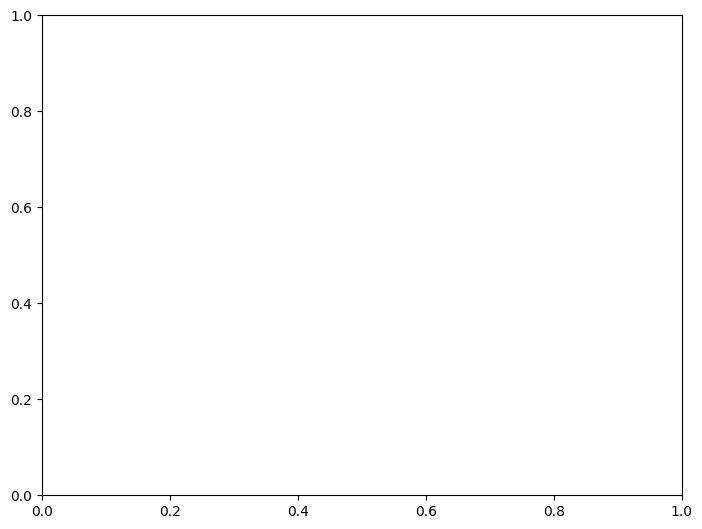

In [16]:
node = "Class:Caudoviricetes"

descendants = nx.descendants(G_vmr, node)
sub_nodes = descendants | {node}
subG = G_vmr.subgraph(sub_nodes)
nx.draw(subG)

# Comparison

In [14]:
# Normalize names for comparison (strip rank prefix, lowercase)
def node_names(G):
    return {n.split(":", 1)[-1].lower() for n in G.nodes}

ncbi_names = node_names(G_viruses)  # or G_ncbi
vmr_names  = node_names(G_vmr)

shared   = ncbi_names & vmr_names
only_ncbi = ncbi_names - vmr_names
only_vmr  = vmr_names  - ncbi_names

print(f"Shared taxa:      {len(shared)}")
print(f"Only in NCBI:     {len(only_ncbi)}")
print(f"Only in VMR:      {len(only_vmr)}")
print(f"Jaccard similarity: {len(shared)/len(ncbi_names | vmr_names):.3f}")

# Compare tree depth
print(f"NCBI max depth: {nx.dag_longest_path_length(G_viruses)}")
print(f"VMR  max depth: {nx.dag_longest_path_length(G_vmr)}")

# Taxa in VMR but missing from NCBI (potential new/unclassified taxa)
print("\nIn VMR but not NCBI (sample):", list(only_vmr)[:10])

Shared taxa:      18637
Only in NCBI:     313749
Only in VMR:      1894
Jaccard similarity: 0.056
NCBI max depth: 15
VMR  max depth: 7

In VMR but not NCBI (sample): ['koteshevirus solicola', 'bartovirus terradaptatum', 'nipunavirus quinobequin', 'fussvirus eyrgjafa', 'sirevirus glycinis', 'giliycovirus radicihabitans', 'giliycovirus caenihabitans', 'pinlevirus segetivivens', 'alcestovirus geovivens', 'chitwivirus']
